In [5]:
# ============================================================
# CELL 1 — Generate and save the delivery dataset as CSV
# Run this cell first — it creates your dataset file
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

# ── City coordinates (latitude, longitude) ──────────────────
city_coords = {
    'Warehouse'   : (20.5937,  78.9629),
    'Mumbai'      : (19.0760,  72.8777),
    'Delhi'       : (28.6139,  77.2090),
    'Bangalore'   : (12.9716,  77.5946),
    'Chennai'     : (13.0827,  80.2707),
    'Kolkata'     : (22.5726,  88.3639),
    'Hyderabad'   : (17.3850,  78.4867),
    'Pune'        : (18.5204,  73.8567),
    'Ahmedabad'   : (23.0225,  72.5714),
    'Jaipur'      : (26.9124,  75.7873),
    'Surat'       : (21.1702,  72.8311),
    'Lucknow'     : (26.8467,  80.9462),
    'Nagpur'      : (21.1458,  79.0882),
    'Indore'      : (22.7196,  75.8577),
    'Bhopal'      : (23.2599,  77.4126),
    'Visakhapatnam': (17.6868, 83.2185),
    'Patna'       : (25.5941,  85.1376),
    'Vadodara'    : (22.3072,  73.1812),
    'Coimbatore'  : (11.0168,  76.9558),
    'Kochi'       : (9.9312,   76.2673),
}

cities     = list(city_coords.keys())
n_cities   = len(cities)
n_routes   = 300

# ── Helper: Haversine distance (km) ─────────────────────────
def haversine(lat1, lon1, lat2, lon2):
    R    = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2 +
            np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) *
            np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

# ── Build route records ──────────────────────────────────────
records = []
for i in range(n_routes):
    origin_idx = 0                                      # always from Warehouse
    dest_idx   = np.random.randint(1, n_cities)
    origin     = cities[origin_idx]
    dest       = cities[dest_idx]

    lat1, lon1 = city_coords[origin]
    lat2, lon2 = city_coords[dest]
    dist_km    = round(haversine(lat1, lon1, lat2, lon2), 2)

    vehicle      = np.random.choice(['Truck', 'Van', 'Bike'],
                                    p=[0.4, 0.4, 0.2])
    speed_map    = {'Truck': 60, 'Van': 70, 'Bike': 40}
    base_speed   = speed_map[vehicle]
    traffic      = np.random.choice(['Low', 'Medium', 'High'],
                                    p=[0.3, 0.5, 0.2])
    traffic_mult = {'Low': 1.0, 'Medium': 0.80, 'High': 0.60}
    eff_speed    = base_speed * traffic_mult[traffic]
    travel_time  = round(dist_km / eff_speed, 2)

    fuel_rate    = {'Truck': 0.35, 'Van': 0.25, 'Bike': 0.10}
    fuel_cost    = round(dist_km * fuel_rate[vehicle] * 95, 2)  # ₹95/L

    packages     = np.random.randint(1, 25)
    priority     = np.random.choice(['Low', 'Medium', 'High'],
                                    p=[0.3, 0.5, 0.2])
    delivery_ok  = int(np.random.random() > 0.08)              # 92% success

    records.append({
        'route_id'         : f'RTE-{i+1:04d}',
        'origin'           : origin,
        'destination'      : dest,
        'origin_lat'       : lat1,
        'origin_lon'       : lon1,
        'dest_lat'         : lat2,
        'dest_lon'         : lon2,
        'distance_km'      : dist_km,
        'vehicle_type'     : vehicle,
        'traffic_condition': traffic,
        'effective_speed'  : round(eff_speed, 1),
        'travel_time_hrs'  : travel_time,
        'fuel_cost_inr'    : fuel_cost,
        'num_packages'     : packages,
        'priority'         : priority,
        'delivery_success' : delivery_ok,
    })

df = pd.DataFrame(records)
df.to_csv('delivery_routes.csv', index=False)

print("✅ Dataset created — delivery_routes.csv")
print(f"   Rows    : {len(df)}")
print(f"   Columns : {len(df.columns)}")
print(f"\nColumn names:")
for col in df.columns:
    print(f"   {col}")
print("\nFirst 3 rows:")
display(df.head(3))

✅ Dataset created — delivery_routes.csv
   Rows    : 300
   Columns : 16

Column names:
   route_id
   origin
   destination
   origin_lat
   origin_lon
   dest_lat
   dest_lon
   distance_km
   vehicle_type
   traffic_condition
   effective_speed
   travel_time_hrs
   fuel_cost_inr
   num_packages
   priority
   delivery_success

First 3 rows:


,route_id,origin,destination,origin_lat,origin_lon,dest_lat,dest_lon,distance_km,vehicle_type,traffic_condition,effective_speed,travel_time_hrs,fuel_cost_inr,num_packages,priority,delivery_success
0,RTE-0001,Warehouse,Pune,20.5937,78.9629,18.5204,73.8567,582.53,Van,Low,70.0,8.32,13835.09,8,Medium,1
1,RTE-0002,Warehouse,Kochi,20.5937,78.9629,9.9312,76.2673,1220.25,Truck,Medium,48.0,25.42,40573.31,21,Medium,1
2,RTE-0003,Warehouse,Delhi,20.5937,78.9629,28.6139,77.2090,909.22,Van,High,42.0,21.65,21593.98,2,Low,1


In [6]:
# ============================================================
# CELL 2 — Install libraries and imports
# ============================================================

!pip install networkx folium scikit-learn xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.linear_model     import LinearRegression
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics          import mean_absolute_error, mean_squared_error, r2_score
from xgboost                  import XGBRegressor

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [7]:
# ============================================================
# CELL 3 — Load CSV and understand the data
# ============================================================

df = pd.read_csv('delivery_routes.csv')

print("=" * 55)
print("       DELIVERY ROUTES DATASET — OVERVIEW")
print("=" * 55)
print(f"  Rows              : {df.shape[0]}")
print(f"  Columns           : {df.shape[1]}")
print(f"  Missing values    : {df.isnull().sum().sum()}")
print(f"  Unique dest.      : {df['destination'].nunique()}")
print(f"  Vehicle types     : {df['vehicle_type'].unique().tolist()}")
print(f"  Traffic levels    : {df['traffic_condition'].unique().tolist()}")
print(f"  Avg distance (km) : {df['distance_km'].mean():.1f}")
print(f"  Avg travel (hrs)  : {df['travel_time_hrs'].mean():.2f}")
print(f"  Avg fuel cost (₹) : {df['fuel_cost_inr'].mean():.1f}")
print(f"  Delivery success  : {df['delivery_success'].mean()*100:.1f}%")
print("=" * 55)

print("\nData types:")
display(df.dtypes.to_frame('dtype'))

print("\nNumerical summary:")
display(df.describe().round(2))

       DELIVERY ROUTES DATASET — OVERVIEW
  Rows              : 300
  Columns           : 16
  Missing values    : 0
  Unique dest.      : 19
  Vehicle types     : ['Van', 'Truck', 'Bike']
  Traffic levels    : ['Low', 'Medium', 'High']
  Avg distance (km) : 695.9
  Avg travel (hrs)  : 15.35
  Avg fuel cost (₹) : 17177.5
  Delivery success  : 91.3%

Data types:


,dtype
route_id,object
origin,object
destination,object
origin_lat,float64
origin_lon,float64
dest_lat,float64
dest_lon,float64
distance_km,float64
vehicle_type,object
traffic_condition,object



Numerical summary:


,origin_lat,origin_lon,dest_lat,dest_lon,distance_km,effective_speed,travel_time_hrs,fuel_cost_inr,num_packages,delivery_success
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,20.59,78.96,20.58,78.09,695.92,48.87,15.35,17177.50,12.15,0.91
std,0.00,0.00,5.21,4.55,281.21,12.23,8.02,9711.14,7.16,0.28
min,20.59,78.96,9.93,72.57,62.76,24.00,0.90,596.22,1.00,0.00
25%,20.59,78.96,17.69,73.86,551.60,40.00,10.67,8556.89,6.00,1.00
50%,20.59,78.96,22.31,77.21,712.86,48.00,13.94,16930.42,12.00,1.00
75%,20.59,78.96,23.26,80.27,859.94,56.00,20.05,24072.34,19.00,1.00
max,20.59,78.96,28.61,88.36,1220.25,70.00,45.26,40573.31,24.00,1.00


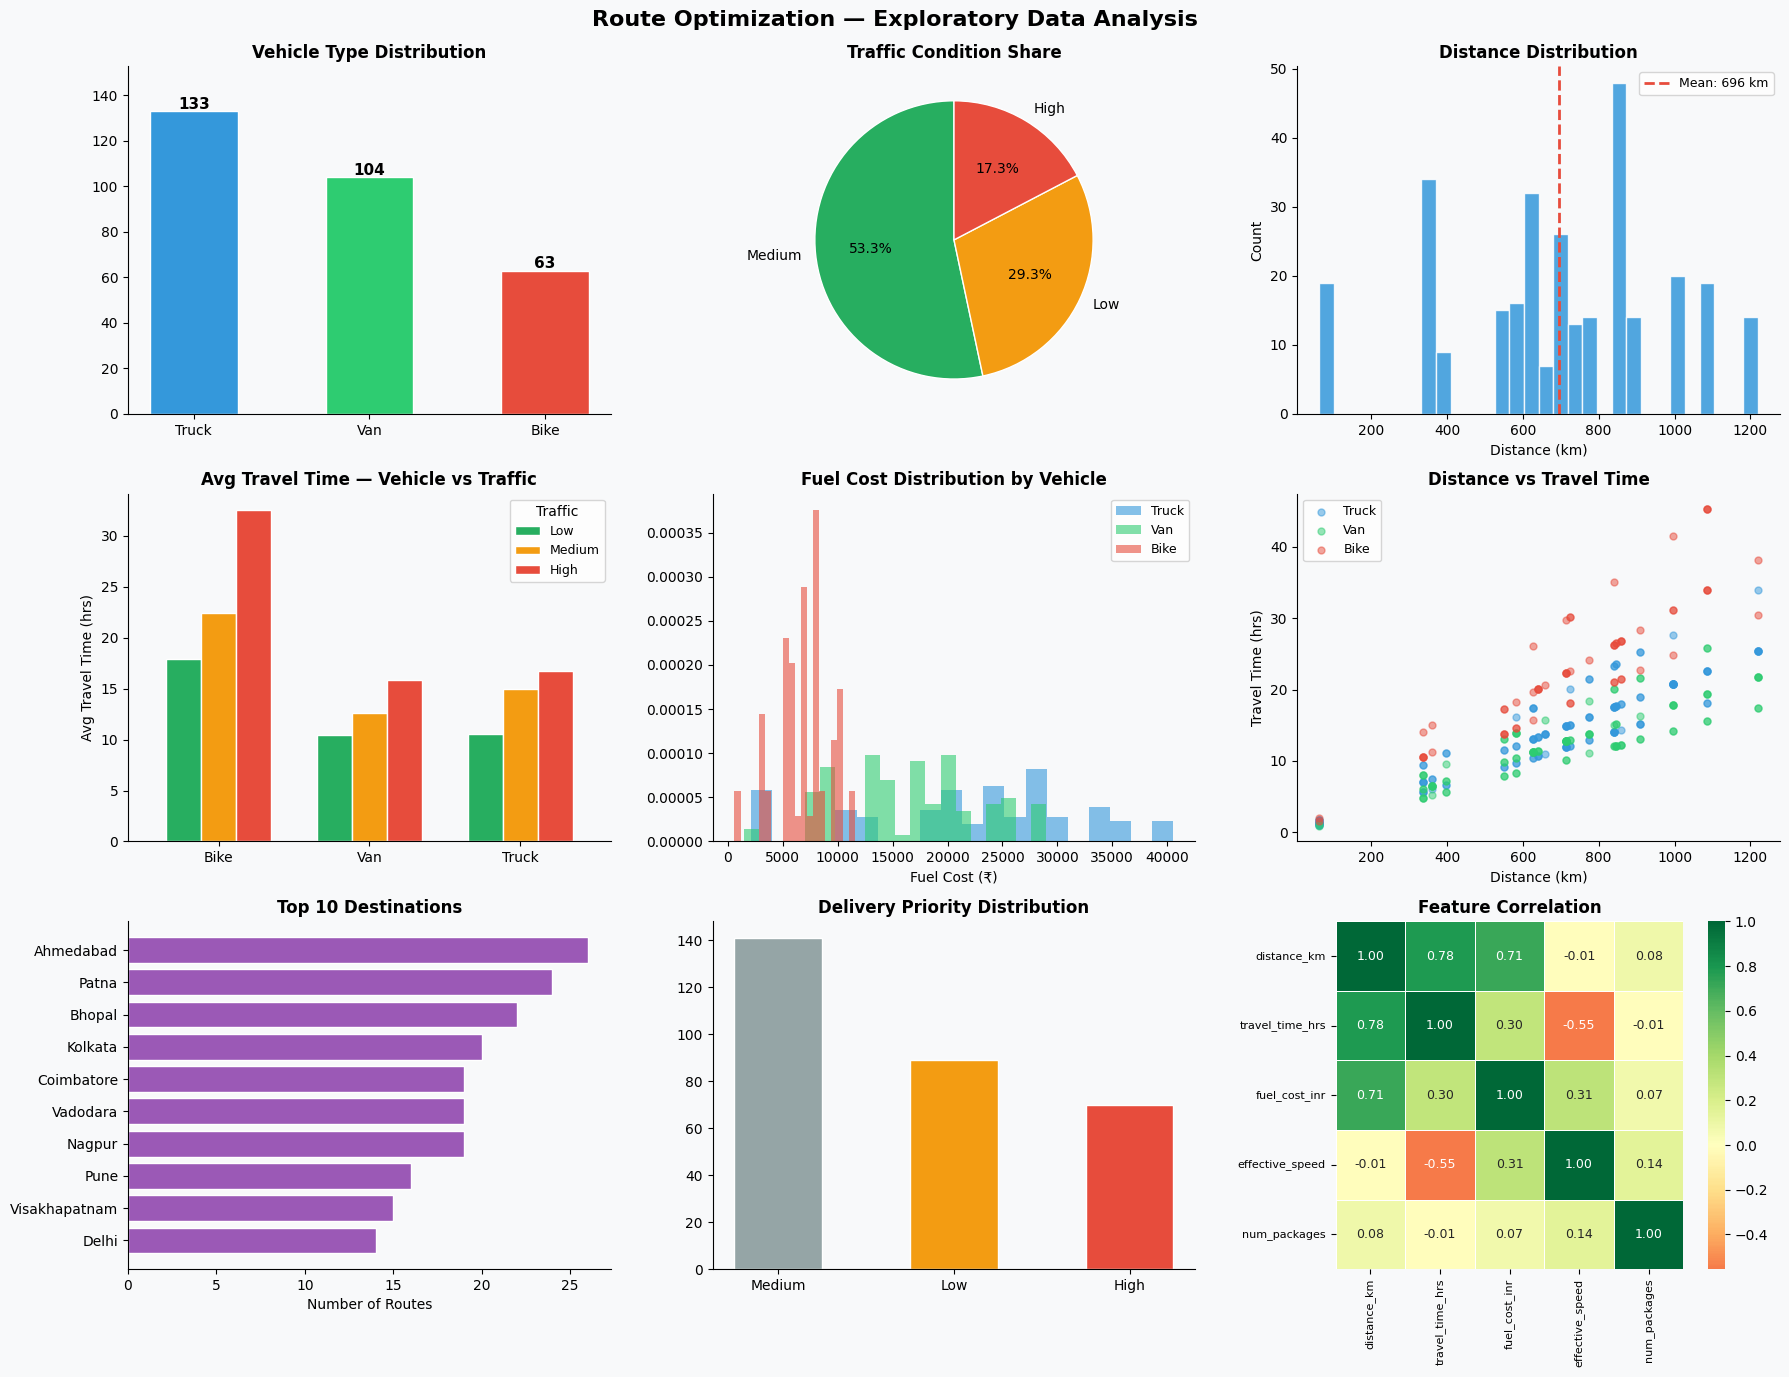

✅ EDA complete!


In [8]:
# ============================================================
# CELL 4 — Visualize the dataset
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Route Optimization — Exploratory Data Analysis',
             fontsize=16, fontweight='bold')
fig.patch.set_facecolor('#f8f9fa')

palette = {'Truck':'#3498db', 'Van':'#2ecc71', 'Bike':'#e74c3c'}

# 1. Vehicle type distribution
ax = axes[0, 0]
vc = df['vehicle_type'].value_counts()
bars = ax.bar(vc.index, vc.values,
              color=[palette[v] for v in vc.index],
              edgecolor='white', width=0.5)
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width()/2,
            b.get_height() + 1, str(v),
            ha='center', fontweight='bold', fontsize=11)
ax.set_title('Vehicle Type Distribution', fontweight='bold')
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, max(vc.values)*1.15)

# 2. Traffic condition distribution
ax = axes[0, 1]
tc = df['traffic_condition'].value_counts()
colors_t = ['#27ae60','#f39c12','#e74c3c']
ax.pie(tc.values, labels=tc.index, colors=colors_t,
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor':'white'})
ax.set_title('Traffic Condition Share', fontweight='bold')

# 3. Distance distribution
ax = axes[0, 2]
ax.hist(df['distance_km'], bins=30, color='#3498db',
        edgecolor='white', alpha=0.85)
ax.axvline(df['distance_km'].mean(), color='#e74c3c',
           linestyle='--', lw=2,
           label=f"Mean: {df['distance_km'].mean():.0f} km")
ax.set_title('Distance Distribution', fontweight='bold')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)

# 4. Travel time by vehicle + traffic
ax = axes[1, 0]
traffic_order = ['Low', 'Medium', 'High']
vehicle_order = ['Bike', 'Van', 'Truck']
grouped = df.groupby(['vehicle_type','traffic_condition'])['travel_time_hrs'].mean().unstack()
grouped = grouped.reindex(index=vehicle_order, columns=traffic_order)
grouped.plot(kind='bar', ax=ax,
             color=['#27ae60','#f39c12','#e74c3c'],
             edgecolor='white', width=0.7, rot=0)
ax.set_title('Avg Travel Time — Vehicle vs Traffic', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Avg Travel Time (hrs)')
ax.legend(title='Traffic', fontsize=9)
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)

# 5. Fuel cost by vehicle type
ax = axes[1, 1]
for vtype, color in palette.items():
    data_v = df[df['vehicle_type']==vtype]['fuel_cost_inr']
    ax.hist(data_v, bins=20, alpha=0.6,
            color=color, label=vtype, density=True)
ax.set_title('Fuel Cost Distribution by Vehicle', fontweight='bold')
ax.set_xlabel('Fuel Cost (₹)')
ax.legend(fontsize=9)
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)

# 6. Distance vs Travel Time scatter
ax = axes[1, 2]
for vtype, color in palette.items():
    mask = df['vehicle_type'] == vtype
    ax.scatter(df.loc[mask,'distance_km'],
               df.loc[mask,'travel_time_hrs'],
               color=color, alpha=0.5, s=25, label=vtype)
ax.set_title('Distance vs Travel Time', fontweight='bold')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Travel Time (hrs)')
ax.legend(fontsize=9)
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)

# 7. Top 10 destinations by route count
ax = axes[2, 0]
top_dest = df['destination'].value_counts().head(10)
ax.barh(top_dest.index[::-1], top_dest.values[::-1],
        color='#9b59b6', edgecolor='white')
ax.set_title('Top 10 Destinations', fontweight='bold')
ax.set_xlabel('Number of Routes')
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)

# 8. Priority distribution
ax = axes[2, 1]
pr = df['priority'].value_counts()
ax.bar(pr.index, pr.values,
       color=['#95a5a6','#f39c12','#e74c3c'],
       edgecolor='white', width=0.5)
ax.set_title('Delivery Priority Distribution', fontweight='bold')
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)

# 9. Correlation heatmap
ax = axes[2, 2]
num_cols = ['distance_km','travel_time_hrs','fuel_cost_inr',
            'effective_speed','num_packages']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size':9}, square=True)
ax.set_title('Feature Correlation', fontweight='bold')
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()
print("✅ EDA complete!")

In [9]:
# ============================================================
# CELL 5 — Feature engineering for ML models
# ============================================================

df_ml = df.copy()

# ── Encode categorical columns ───────────────────────────────
le_vehicle  = LabelEncoder()
le_traffic  = LabelEncoder()
le_priority = LabelEncoder()
le_dest     = LabelEncoder()

df_ml['vehicle_enc']  = le_vehicle.fit_transform(df_ml['vehicle_type'])
df_ml['traffic_enc']  = le_traffic.fit_transform(df_ml['traffic_condition'])
df_ml['priority_enc'] = le_priority.fit_transform(df_ml['priority'])
df_ml['dest_enc']     = le_dest.fit_transform(df_ml['destination'])

# ── New engineered features ───────────────────────────────────
df_ml['cost_per_km']     = (df_ml['fuel_cost_inr'] /
                             df_ml['distance_km']).round(2)
df_ml['time_per_km']     = (df_ml['travel_time_hrs'] /
                             df_ml['distance_km']).round(4)
df_ml['pkg_per_km']      = (df_ml['num_packages'] /
                             df_ml['distance_km']).round(4)
df_ml['efficiency_score']= (df_ml['num_packages'] /
                             (df_ml['travel_time_hrs'] *
                              df_ml['fuel_cost_inr'] + 1)).round(4)

print("✅ Feature engineering done!")
print(f"   New features: cost_per_km, time_per_km, "
      f"pkg_per_km, efficiency_score")
print(f"\nFeature preview:")
display(df_ml[['route_id','distance_km','cost_per_km',
               'time_per_km','efficiency_score']].head(5))

✅ Feature engineering done!
   New features: cost_per_km, time_per_km, pkg_per_km, efficiency_score

Feature preview:


,route_id,distance_km,cost_per_km,time_per_km,efficiency_score
0,RTE-0001,582.53,23.75,0.0143,0.0001
1,RTE-0002,1220.25,33.25,0.0208,0.0000
2,RTE-0003,909.22,23.75,0.0238,0.0000
3,RTE-0004,62.76,23.75,0.0143,0.0127
4,RTE-0005,841.18,33.25,0.0167,0.0000


In [10]:
# ============================================================
# CELL 6 — Train ML models to predict travel_time_hrs
# ============================================================

FEATURES = ['distance_km', 'vehicle_enc', 'traffic_enc',
            'priority_enc', 'num_packages', 'effective_speed',
            'cost_per_km', 'pkg_per_km']
TARGET   = 'travel_time_hrs'

X = df_ml[FEATURES]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    'Linear Regression'   : LinearRegression(),
    'Random Forest'       : RandomForestRegressor(n_estimators=100,
                                random_state=42),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=100,
                                random_state=42),
    'XGBoost'             : XGBRegressor(n_estimators=100,
                                random_state=42, verbosity=0),
}

results = {}

print("=" * 65)
print(f"  {'Model':<25}  {'MAE':>8}  {'RMSE':>8}  {'R² Score':>9}")
print("=" * 65)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {
        'model' : model,
        'mae'   : mae,
        'rmse'  : rmse,
        'r2'    : r2,
        'y_pred': y_pred,
    }
    print(f"  {name:<25}  {mae:>8.4f}  {rmse:>8.4f}  {r2:>9.4f}")

print("=" * 65)
best_ml = max(results, key=lambda k: results[k]['r2'])
print(f"\n🏆 Best model: {best_ml}  (R² = {results[best_ml]['r2']:.4f})")

  Model                           MAE      RMSE   R² Score
  Linear Regression            1.5251    2.6159     0.9179
  Random Forest                0.4206    0.7597     0.9931
  Gradient Boosting            0.3018    0.4904     0.9971
  XGBoost                      0.4114    0.8191     0.9920

🏆 Best model: Gradient Boosting  (R² = 0.9971)


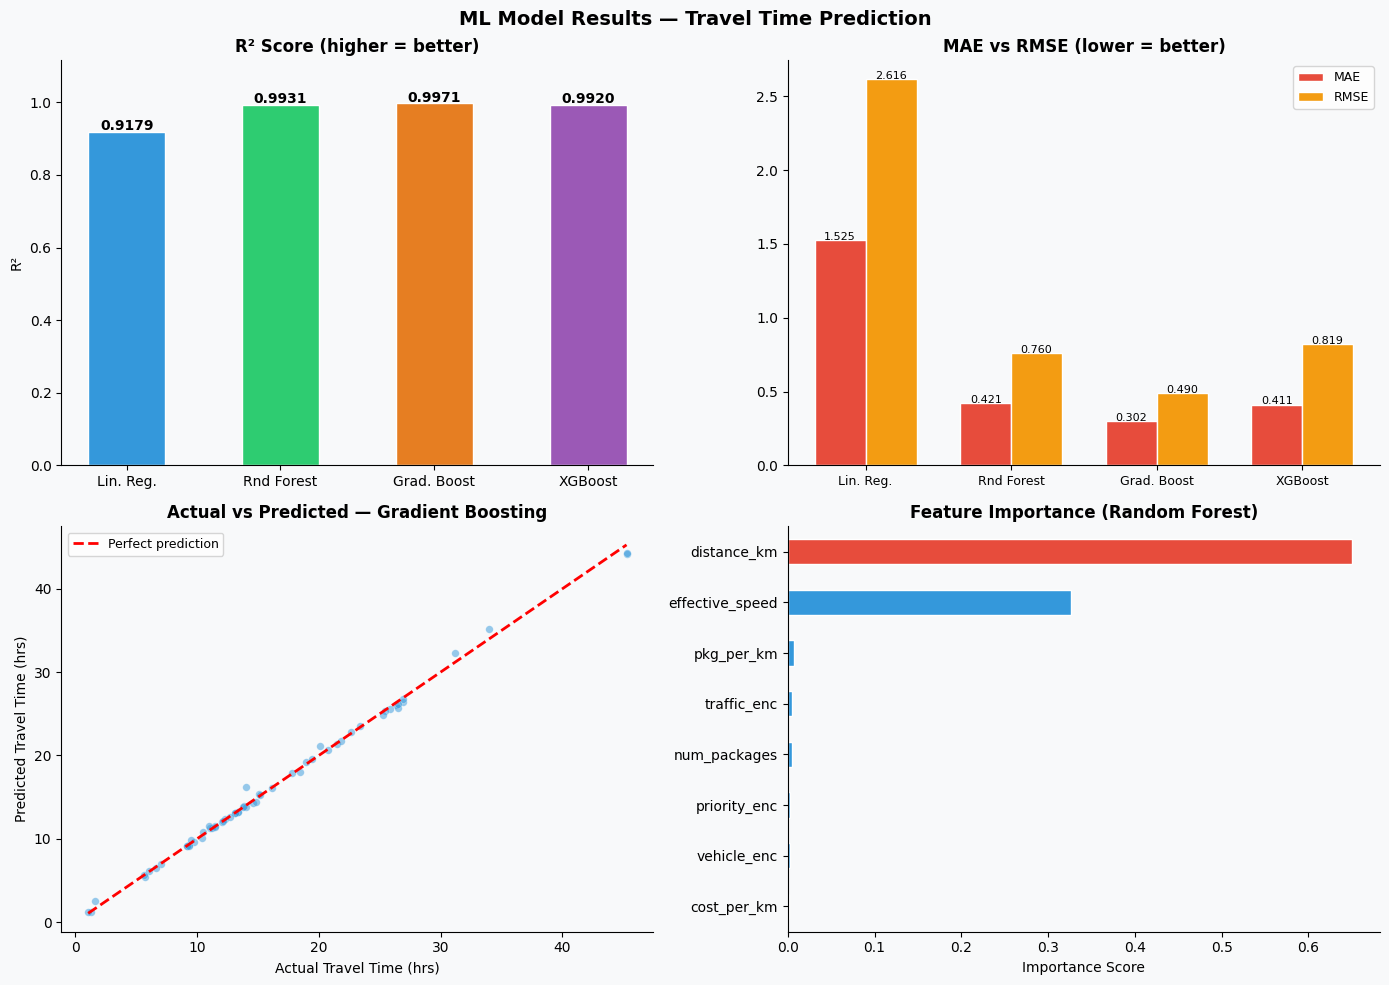

✅ ML visualization complete!


In [11]:
# ============================================================
# CELL 7 — Visualize ML model performance
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ML Model Results — Travel Time Prediction',
             fontsize=14, fontweight='bold')
fig.patch.set_facecolor('#f8f9fa')

model_names = list(results.keys())
short       = ['Lin. Reg.', 'Rnd Forest', 'Grad. Boost', 'XGBoost']
r2_vals     = [results[m]['r2']   for m in model_names]
mae_vals    = [results[m]['mae']  for m in model_names]
rmse_vals   = [results[m]['rmse'] for m in model_names]
colors_ml   = ['#3498db','#2ecc71','#e67e22','#9b59b6']

# 1. R² score comparison
ax = axes[0, 0]
bars = ax.bar(short, r2_vals, color=colors_ml, edgecolor='white', width=0.5)
for b, v in zip(bars, r2_vals):
    ax.text(b.get_x()+b.get_width()/2,
            b.get_height()+0.005,
            f'{v:.4f}', ha='center',
            fontsize=10, fontweight='bold')
ax.set_title('R² Score (higher = better)', fontweight='bold')
ax.set_ylim(0, max(r2_vals)*1.12)
ax.set_ylabel('R²')
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)

# 2. MAE + RMSE grouped bar
ax    = axes[0, 1]
x     = np.arange(len(short))
width = 0.35
b1    = ax.bar(x - width/2, mae_vals,  width,
               color='#e74c3c', label='MAE',  edgecolor='white')
b2    = ax.bar(x + width/2, rmse_vals, width,
               color='#f39c12', label='RMSE', edgecolor='white')
for b, v in zip(b1, mae_vals):
    ax.text(b.get_x()+b.get_width()/2,
            b.get_height()+0.001,
            f'{v:.3f}', ha='center', fontsize=8)
for b, v in zip(b2, rmse_vals):
    ax.text(b.get_x()+b.get_width()/2,
            b.get_height()+0.001,
            f'{v:.3f}', ha='center', fontsize=8)
ax.set_title('MAE vs RMSE (lower = better)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short, fontsize=9)
ax.legend(fontsize=9)
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)

# 3. Actual vs Predicted scatter (best model)
ax      = axes[1, 0]
y_pred_best = results[best_ml]['y_pred']
ax.scatter(y_test, y_pred_best, alpha=0.5,
           color='#3498db', s=30, edgecolors='white', lw=0.3)
mn = min(y_test.min(), y_pred_best.min())
mx = max(y_test.max(), y_pred_best.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Travel Time (hrs)', fontsize=10)
ax.set_ylabel('Predicted Travel Time (hrs)', fontsize=10)
ax.set_title(f'Actual vs Predicted — {best_ml}', fontweight='bold')
ax.legend(fontsize=9)
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)

# 4. Feature importance (Random Forest)
ax = axes[1, 1]
rf_imp   = results['Random Forest']['model'].feature_importances_
feat_imp = pd.Series(rf_imp, index=FEATURES).sort_values(ascending=True)
colors_imp = ['#e74c3c' if v == feat_imp.max()
              else '#3498db' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Feature Importance (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()
print(f"✅ ML visualization complete!")

In [12]:
# ============================================================
# CELL 8 — Build a weighted delivery graph
# Nodes = cities, Edges = routes, Weight = travel time
# ============================================================

city_coords = {
    'Warehouse'   : (20.5937,  78.9629),
    'Mumbai'      : (19.0760,  72.8777),
    'Delhi'       : (28.6139,  77.2090),
    'Bangalore'   : (12.9716,  77.5946),
    'Chennai'     : (13.0827,  80.2707),
    'Kolkata'     : (22.5726,  88.3639),
    'Hyderabad'   : (17.3850,  78.4867),
    'Pune'        : (18.5204,  73.8567),
    'Ahmedabad'   : (23.0225,  72.5714),
    'Jaipur'      : (26.9124,  75.7873),
    'Surat'       : (21.1702,  72.8311),
    'Lucknow'     : (26.8467,  80.9462),
    'Nagpur'      : (21.1458,  79.0882),
    'Indore'      : (22.7196,  75.8577),
    'Bhopal'      : (23.2599,  77.4126),
    'Visakhapatnam': (17.6868, 83.2185),
    'Patna'       : (25.5941,  85.1376),
    'Vadodara'    : (22.3072,  73.1812),
    'Coimbatore'  : (11.0168,  76.9558),
    'Kochi'       : (9.9312,   76.2673),
}

def haversine(lat1, lon1, lat2, lon2):
    R    = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2 +
            np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*
            np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

G = nx.Graph()

# Add all cities as nodes
for city, (lat, lon) in city_coords.items():
    G.add_node(city, lat=lat, lon=lon)

# Add edges from the dataset (avg travel time per route)
route_summary = (df.groupby(['origin','destination'])
                   .agg(avg_time    = ('travel_time_hrs','mean'),
                        avg_dist    = ('distance_km','mean'),
                        avg_cost    = ('fuel_cost_inr','mean'),
                        route_count = ('route_id','count'))
                   .reset_index())

for _, row in route_summary.iterrows():
    G.add_edge(
        row['origin'], row['destination'],
        weight      = round(row['avg_time'], 3),
        distance    = round(row['avg_dist'], 1),
        cost        = round(row['avg_cost'], 1),
        route_count = int(row['route_count'])
    )

print("✅ Delivery graph constructed!")
print(f"   Nodes (cities) : {G.number_of_nodes()}")
print(f"   Edges (routes) : {G.number_of_edges()}")
print(f"   Is connected   : {nx.is_connected(G)}")

✅ Delivery graph constructed!
   Nodes (cities) : 20
   Edges (routes) : 19
   Is connected   : True


In [13]:
# ============================================================
# CELL 9 — Dijkstra's algorithm (shortest / fastest path)
# ============================================================

def find_best_route(G, source, target, weight='weight'):
    """
    Returns the optimal path and total cost
    between source and target using Dijkstra.
    """
    try:
        path   = nx.dijkstra_path(G, source, target, weight=weight)
        length = nx.dijkstra_path_length(G, source, target, weight=weight)
        return path, round(length, 3)
    except nx.NetworkXNoPath:
        return None, float('inf')
    except nx.NodeNotFound as e:
        print(f"   Node not found: {e}")
        return None, float('inf')

# ── Test multiple source → destination pairs ─────────────────
test_routes = [
    ('Warehouse', 'Mumbai'),
    ('Warehouse', 'Delhi'),
    ('Warehouse', 'Bangalore'),
    ('Warehouse', 'Kolkata'),
    ('Warehouse', 'Chennai'),
]

print("=" * 60)
print("  DIJKSTRA'S SHORTEST PATH RESULTS")
print("=" * 60)

for src, dst in test_routes:
    path, cost = find_best_route(G, src, dst, weight='weight')
    if path:
        # Get total distance along path
        total_dist = sum(
            G[path[i]][path[i+1]].get('distance', 0)
            for i in range(len(path)-1)
        )
        print(f"\n  {src} → {dst}")
        print(f"    Path     : {' → '.join(path)}")
        print(f"    Time     : {cost:.2f} hrs")
        print(f"    Distance : {total_dist:.1f} km")
    else:
        print(f"\n  {src} → {dst} : No path found")

print("\n" + "=" * 60)

  DIJKSTRA'S SHORTEST PATH RESULTS

  Warehouse → Mumbai
    Path     : Warehouse → Mumbai
    Time     : 14.59 hrs
    Distance : 658.4 km

  Warehouse → Delhi
    Path     : Warehouse → Delhi
    Time     : 19.32 hrs
    Distance : 909.2 km

  Warehouse → Bangalore
    Path     : Warehouse → Bangalore
    Time     : 19.15 hrs
    Distance : 859.9 km

  Warehouse → Kolkata
    Path     : Warehouse → Kolkata
    Time     : 22.14 hrs
    Distance : 996.4 km

  Warehouse → Chennai
    Path     : Warehouse → Chennai
    Time     : 17.81 hrs
    Distance : 846.7 km



In [14]:
# ============================================================
# CELL 10 — TSP: visit all cities, minimize total time
# Step 1: Nearest Neighbor heuristic
# Step 2: 2-Opt improvement
# ============================================================

# Build a complete distance matrix from coordinates
cities_list = list(city_coords.keys())

def build_time_matrix(cities, G):
    """
    Build a full NxN matrix of shortest travel times
    using Dijkstra between every pair.
    """
    n      = len(cities)
    matrix = np.full((n, n), float('inf'))
    np.fill_diagonal(matrix, 0)

    for i, c1 in enumerate(cities):
        for j, c2 in enumerate(cities):
            if i != j:
                try:
                    t = nx.dijkstra_path_length(
                        G, c1, c2, weight='weight')
                    matrix[i][j] = t
                except (nx.NetworkXNoPath, nx.NodeNotFound):
                    matrix[i][j] = 9999
    return matrix

print("⏳ Building time matrix (may take ~10s)...")
time_matrix = build_time_matrix(cities_list, G)
print("✅ Time matrix built!")

# ── Nearest Neighbor Heuristic ───────────────────────────────
def nearest_neighbor_tsp(matrix, cities, start=0):
    n         = len(cities)
    unvisited = set(range(n)) - {start}
    route     = [start]
    current   = start
    total     = 0

    while unvisited:
        nearest   = min(unvisited,
                        key=lambda j: matrix[current][j])
        total    += matrix[current][nearest]
        route.append(nearest)
        unvisited.remove(nearest)
        current   = nearest

    # Return to start
    total += matrix[current][start]
    route.append(start)
    return route, round(total, 2)

# ── 2-Opt Improvement ────────────────────────────────────────
def route_cost(matrix, route):
    return sum(matrix[route[i]][route[i+1]]
               for i in range(len(route)-1))

def two_opt(matrix, route):
    best      = route[:]
    best_cost = route_cost(matrix, best)
    improved  = True

    while improved:
        improved = False
        for i in range(1, len(best)-2):
            for j in range(i+1, len(best)-1):
                new_route = best[:i] + best[i:j+1][::-1] + best[j+1:]
                new_cost  = route_cost(matrix, new_route)
                if new_cost < best_cost:
                    best      = new_route
                    best_cost = new_cost
                    improved  = True

    return best, round(best_cost, 2)

# ── Run both algorithms ──────────────────────────────────────
nn_route, nn_cost   = nearest_neighbor_tsp(time_matrix, cities_list, start=0)
opt_route, opt_cost = two_opt(time_matrix, nn_route)

saving    = nn_cost - opt_cost
saving_pct= saving / nn_cost * 100 if nn_cost > 0 else 0

print("\n" + "=" * 55)
print("  TSP ROUTE OPTIMIZATION RESULTS")
print("=" * 55)
print(f"\n  Nearest Neighbor total time : {nn_cost:.2f} hrs")
print(f"  2-Opt improved total time   : {opt_cost:.2f} hrs")
print(f"  Time saved                  : {saving:.2f} hrs")
print(f"  Improvement                 : {saving_pct:.1f}%")
print(f"\n  Optimized route:")
print("  " + " → ".join([cities_list[i] for i in opt_route]))

⏳ Building time matrix (may take ~10s)...
✅ Time matrix built!

  TSP ROUTE OPTIMIZATION RESULTS

  Nearest Neighbor total time : 579.94 hrs
  2-Opt improved total time   : 579.94 hrs
  Time saved                  : 0.00 hrs
  Improvement                 : 0.0%

  Optimized route:
  Warehouse → Nagpur → Hyderabad → Bhopal → Indore → Visakhapatnam → Pune → Vadodara → Surat → Coimbatore → Kochi → Kolkata → Delhi → Bangalore → Patna → Lucknow → Chennai → Jaipur → Ahmedabad → Mumbai → Warehouse


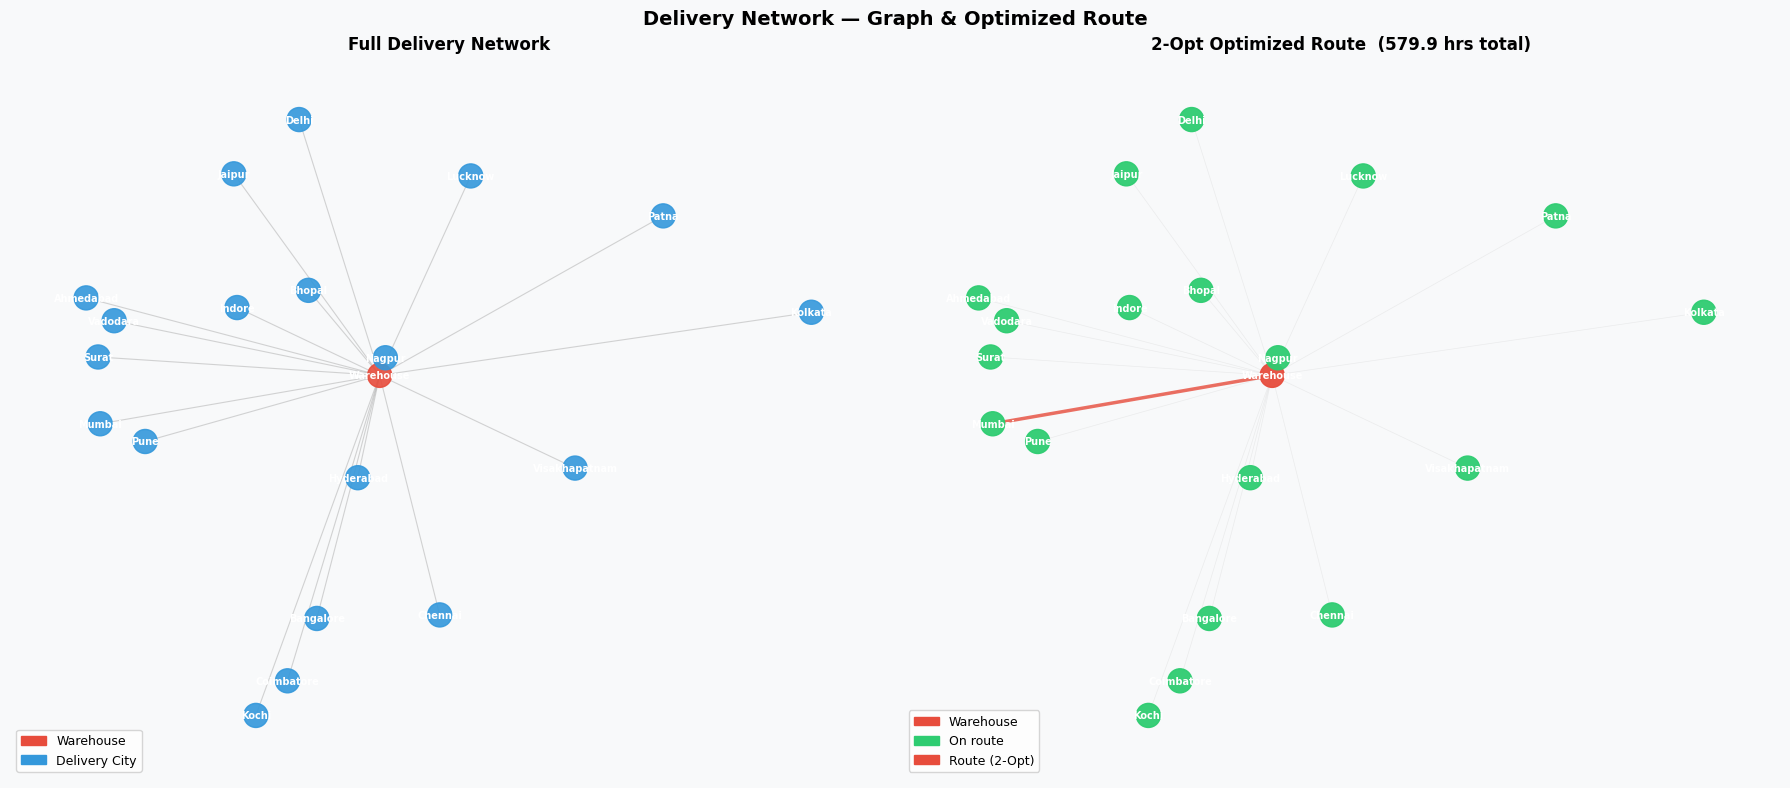

✅ Graph visualization complete!


In [15]:
# ============================================================
# CELL 11 — Draw delivery network and optimized TSP route
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle('Delivery Network — Graph & Optimized Route',
             fontsize=14, fontweight='bold')

# Use (lon, lat) as position so it maps geographically
pos = {city: (lon, lat) for city, (lat, lon)
       in city_coords.items()}

# ── LEFT: Full delivery network ───────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#eaf3fb')

nx.draw_networkx_edges(G, pos, ax=ax1,
                       edge_color='#aaaaaa',
                       width=0.8, alpha=0.5)

node_colors = ['#e74c3c' if n == 'Warehouse'
               else '#3498db' for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1,
                       node_color=node_colors,
                       node_size=300, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax1,
                        font_size=7, font_color='white',
                        font_weight='bold')

ax1.set_title('Full Delivery Network', fontweight='bold', fontsize=12)
ax1.axis('off')

patch_wh = mpatches.Patch(color='#e74c3c', label='Warehouse')
patch_ct = mpatches.Patch(color='#3498db', label='Delivery City')
ax1.legend(handles=[patch_wh, patch_ct],
           loc='lower left', fontsize=9)

# ── RIGHT: Optimized TSP route ────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#eaf3fb')

# All edges light
nx.draw_networkx_edges(G, pos, ax=ax2,
                       edge_color='#cccccc',
                       width=0.5, alpha=0.3)

# Highlight optimized route edges
opt_edge_list = []
for i in range(len(opt_route) - 1):
    c1 = cities_list[opt_route[i]]
    c2 = cities_list[opt_route[i+1]]
    if G.has_edge(c1, c2):
        opt_edge_list.append((c1, c2))

nx.draw_networkx_edges(G, pos, edgelist=opt_edge_list,
                       ax=ax2, edge_color='#e74c3c',
                       width=2.5, alpha=0.8,
                       arrows=True, arrowsize=15)

# Node colors
nc = ['#e74c3c' if n == 'Warehouse'
      else '#2ecc71' if n in [cities_list[i] for i in opt_route]
      else '#aaaaaa' for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax2,
                       node_color=nc,
                       node_size=300, alpha=0.95)
nx.draw_networkx_labels(G, pos, ax=ax2,
                        font_size=7, font_color='white',
                        font_weight='bold')

ax2.set_title(f'2-Opt Optimized Route  '
              f'({opt_cost:.1f} hrs total)',
              fontweight='bold', fontsize=12)
ax2.axis('off')

patch_wh  = mpatches.Patch(color='#e74c3c', label='Warehouse')
patch_vis = mpatches.Patch(color='#2ecc71', label='On route')
patch_rt  = mpatches.Patch(color='#e74c3c',
                            label=f'Route (2-Opt)')
ax2.legend(handles=[patch_wh, patch_vis, patch_rt],
           loc='lower left', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()
print("✅ Graph visualization complete!")

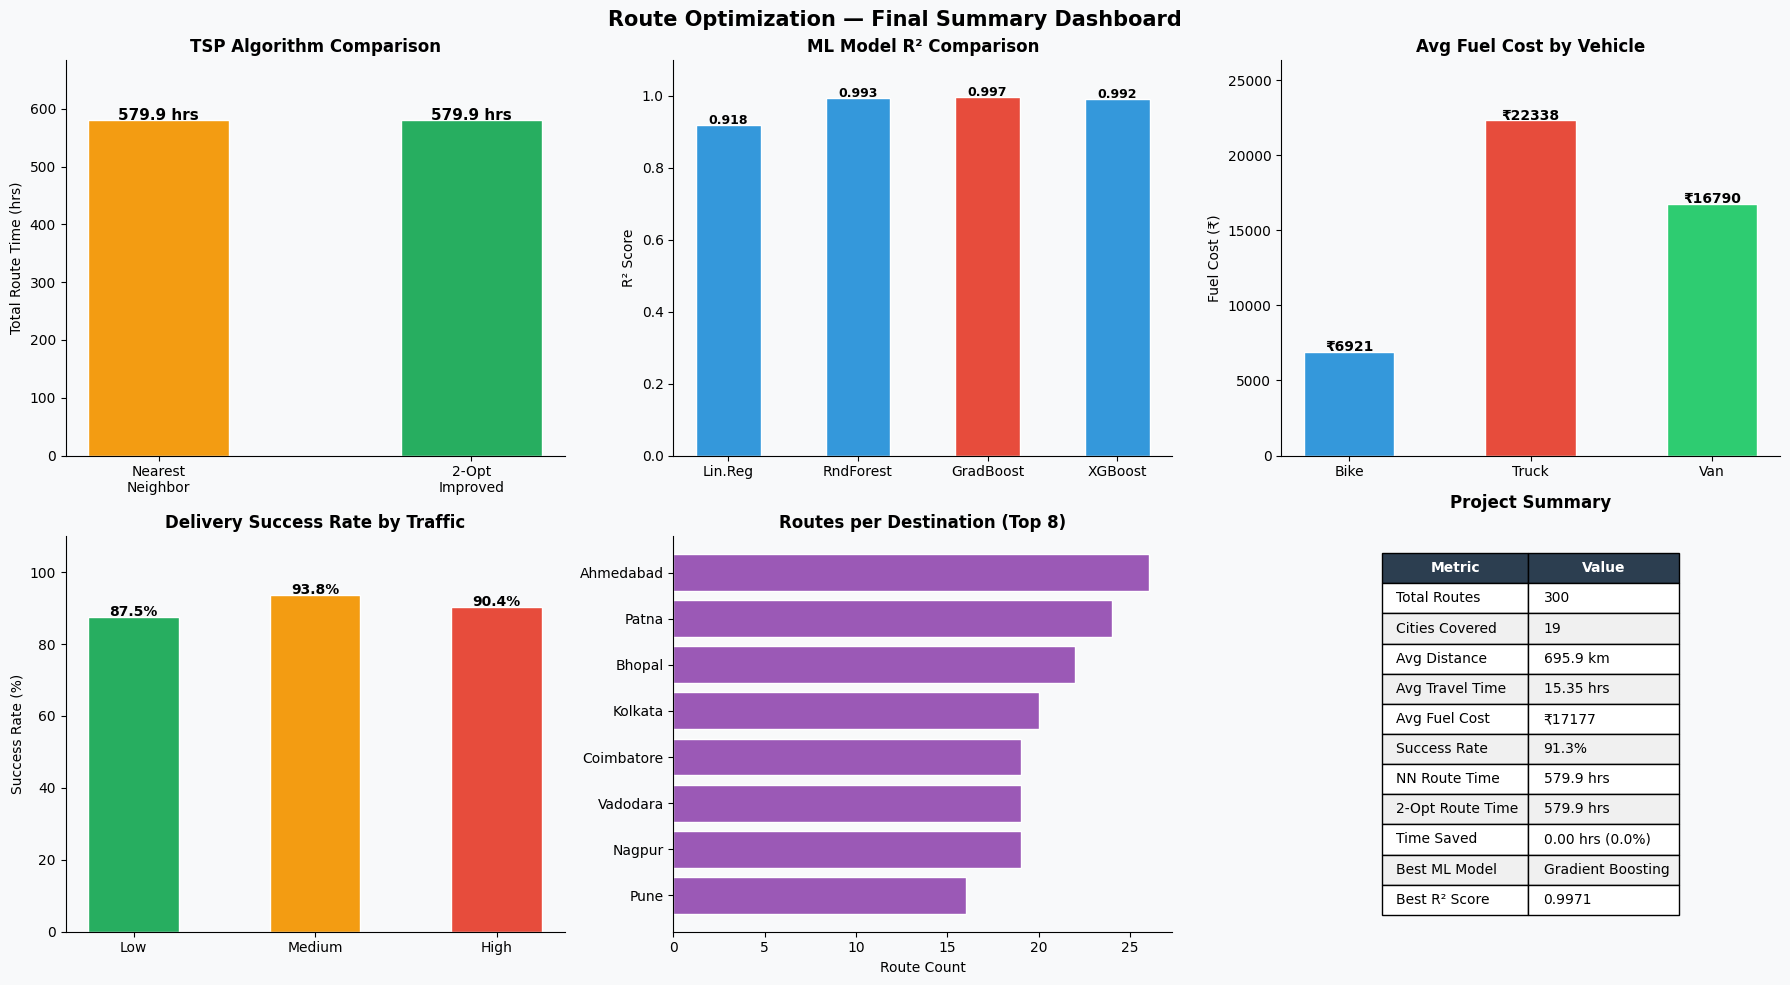

✅ Dashboard complete!


In [16]:
# ============================================================
# CELL 12 — Final summary: costs, savings, model results
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle('Route Optimization — Final Summary Dashboard',
             fontsize=15, fontweight='bold')

# 1. Algorithm comparison
ax = axes[0, 0]
algos    = ['Nearest\nNeighbor', '2-Opt\nImproved']
times    = [nn_cost, opt_cost]
cols_a   = ['#f39c12', '#27ae60']
bars     = ax.bar(algos, times, color=cols_a,
                  edgecolor='white', width=0.45)
for b, v in zip(bars, times):
    ax.text(b.get_x()+b.get_width()/2,
            b.get_height()+0.5,
            f'{v:.1f} hrs', ha='center',
            fontweight='bold', fontsize=11)
ax.set_title('TSP Algorithm Comparison', fontweight='bold')
ax.set_ylabel('Total Route Time (hrs)')
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, max(times)*1.18)

# 2. ML model R² comparison
ax = axes[0, 1]
ml_names  = list(results.keys())
ml_short  = ['Lin.Reg', 'RndForest', 'GradBoost', 'XGBoost']
r2_list   = [results[m]['r2'] for m in ml_names]
col_ml    = ['#e74c3c' if m == best_ml else '#3498db' for m in ml_names]
bars2     = ax.bar(ml_short, r2_list, color=col_ml,
                   edgecolor='white', width=0.5)
for b, v in zip(bars2, r2_list):
    ax.text(b.get_x()+b.get_width()/2,
            b.get_height()+0.003,
            f'{v:.3f}', ha='center', fontsize=9,
            fontweight='bold')
ax.set_title('ML Model R² Comparison', fontweight='bold')
ax.set_ylabel('R² Score')
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, 1.1)

# 3. Avg fuel cost by vehicle
ax = axes[0, 2]
fuel_by_v = df.groupby('vehicle_type')['fuel_cost_inr'].mean()
ax.bar(fuel_by_v.index, fuel_by_v.values,
       color=['#3498db','#e74c3c','#2ecc71'],
       edgecolor='white', width=0.5)
for i, v in enumerate(fuel_by_v.values):
    ax.text(i, v+20, f'₹{v:.0f}',
            ha='center', fontweight='bold', fontsize=10)
ax.set_title('Avg Fuel Cost by Vehicle', fontweight='bold')
ax.set_ylabel('Fuel Cost (₹)')
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, max(fuel_by_v.values)*1.18)

# 4. Delivery success by traffic condition
ax = axes[1, 0]
success = df.groupby('traffic_condition')['delivery_success'].mean()*100
order   = ['Low','Medium','High']
success = success.reindex(order)
ax.bar(success.index, success.values,
       color=['#27ae60','#f39c12','#e74c3c'],
       edgecolor='white', width=0.5)
for i, v in enumerate(success.values):
    ax.text(i, v+0.3, f'{v:.1f}%',
            ha='center', fontweight='bold', fontsize=10)
ax.set_title('Delivery Success Rate by Traffic', fontweight='bold')
ax.set_ylabel('Success Rate (%)')
ax.set_ylim(0, 110)
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)

# 5. Route count per destination (top 8)
ax = axes[1, 1]
top8 = df['destination'].value_counts().head(8)
ax.barh(top8.index[::-1], top8.values[::-1],
        color='#9b59b6', edgecolor='white')
ax.set_title('Routes per Destination (Top 8)',
             fontweight='bold')
ax.set_xlabel('Route Count')
ax.set_facecolor('#f8f9fa')
ax.spines[['top','right']].set_visible(False)

# 6. Summary stats table
ax = axes[1, 2]
ax.axis('off')
summary_data = [
    ['Total Routes',      str(len(df))],
    ['Cities Covered',    str(df['destination'].nunique())],
    ['Avg Distance',      f"{df['distance_km'].mean():.1f} km"],
    ['Avg Travel Time',   f"{df['travel_time_hrs'].mean():.2f} hrs"],
    ['Avg Fuel Cost',     f"₹{df['fuel_cost_inr'].mean():.0f}"],
    ['Success Rate',      f"{df['delivery_success'].mean()*100:.1f}%"],
    ['NN Route Time',     f"{nn_cost:.1f} hrs"],
    ['2-Opt Route Time',  f"{opt_cost:.1f} hrs"],
    ['Time Saved',        f"{saving:.2f} hrs ({saving_pct:.1f}%)"],
    ['Best ML Model',     best_ml],
    ['Best R² Score',     f"{results[best_ml]['r2']:.4f}"],
]

tbl = ax.table(cellText=summary_data,
               colLabels=['Metric', 'Value'],
               loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
tbl.auto_set_column_width([0, 1])

for col in range(2):
    tbl[(0, col)].set_facecolor('#2c3e50')
    tbl[(0, col)].set_text_props(color='white', fontweight='bold')
for row in range(1, len(summary_data)+1):
    bg = '#f0f0f0' if row % 2 == 0 else 'white'
    for col in range(2):
        tbl[(row, col)].set_facecolor(bg)

ax.set_title('Project Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()
print("✅ Dashboard complete!")

In [17]:
# ============================================================
# CELL 13 — Save results and download from Colab
# ============================================================
import pickle
from google.colab import files

# Save processed dataset
df_ml.to_csv('delivery_routes_processed.csv', index=False)

# Save best ML model
with open('best_route_model.pkl', 'wb') as f:
    pickle.dump(results[best_ml]['model'], f)

# Save optimized route as CSV
opt_route_df = pd.DataFrame({
    'stop_order' : range(len(opt_route)),
    'city'       : [cities_list[i] for i in opt_route],
    'latitude'   : [city_coords[cities_list[i]][0] for i in opt_route],
    'longitude'  : [city_coords[cities_list[i]][1] for i in opt_route],
})
opt_route_df.to_csv('optimized_route.csv', index=False)

# Download all files
files.download('delivery_routes.csv')
files.download('delivery_routes_processed.csv')
files.download('optimized_route.csv')
files.download('best_route_model.pkl')

print("=" * 55)
print("  FILES SAVED & DOWNLOADED")
print("=" * 55)
print("  delivery_routes.csv           — raw dataset")
print("  delivery_routes_processed.csv — with features")
print("  optimized_route.csv           — 2-opt TSP route")
print("  best_route_model.pkl          — trained ML model")
print("=" * 55)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  FILES SAVED & DOWNLOADED
  delivery_routes.csv           — raw dataset
  delivery_routes_processed.csv — with features
  optimized_route.csv           — 2-opt TSP route
  best_route_model.pkl          — trained ML model
